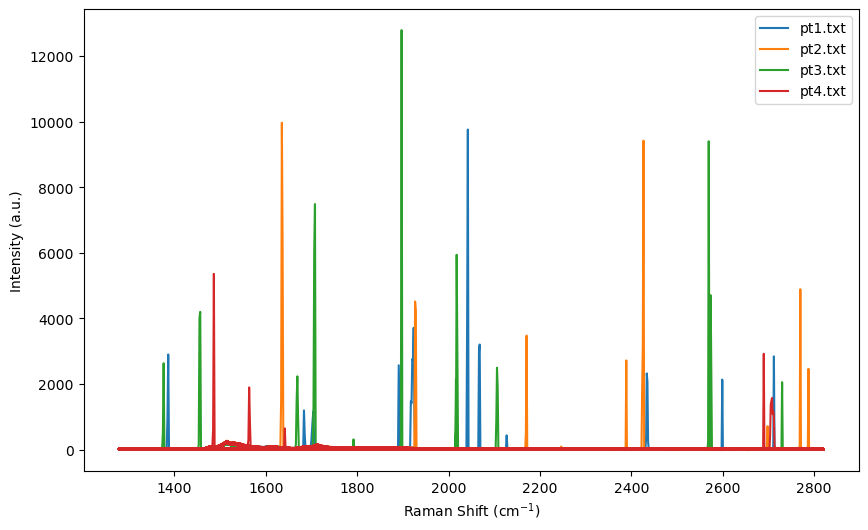

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob

file_list = sorted(glob.glob("pt*.txt"))

plt.figure(figsize=(10, 6))

for file in file_list:
    data_array = np.loadtxt(file, usecols=(2, 3), delimiter='\t', unpack=True, skiprows=1)
    x, y = data_array
    plt.plot(x, y, linestyle='-', label=file)

plt.xlabel('Raman Shift (cm$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.legend()
plt.show()


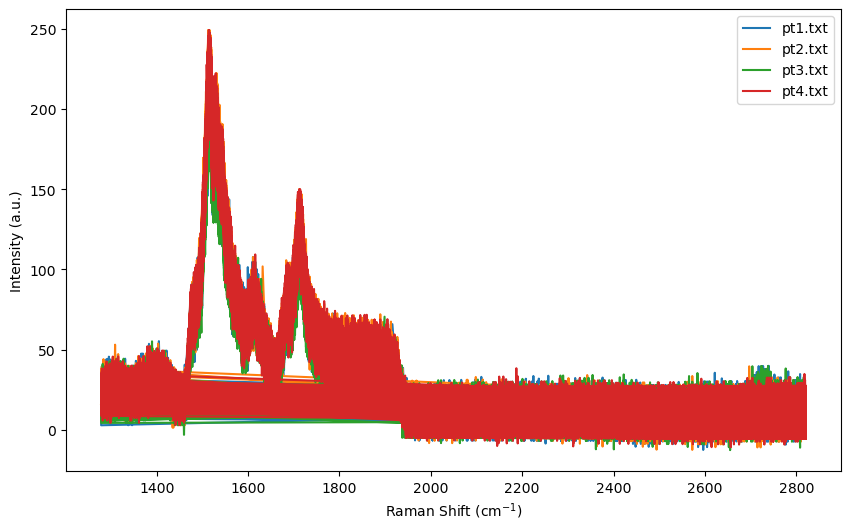

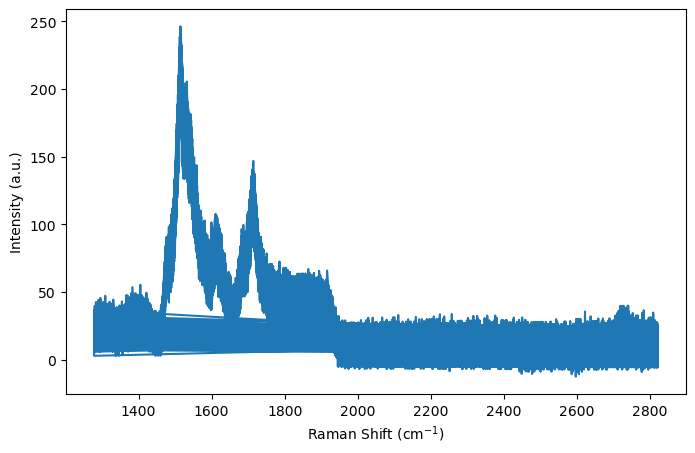

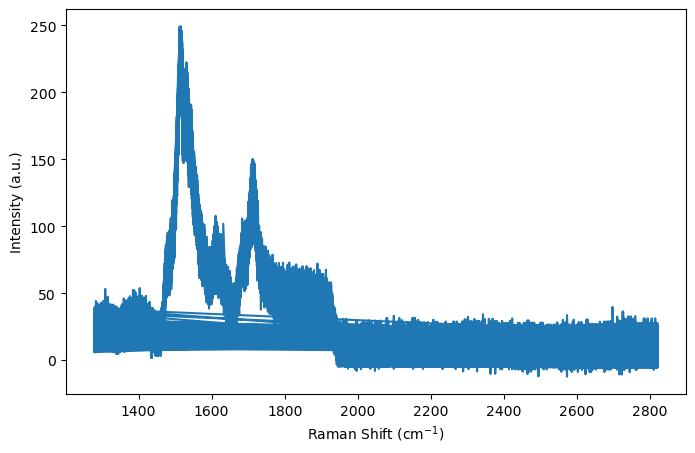

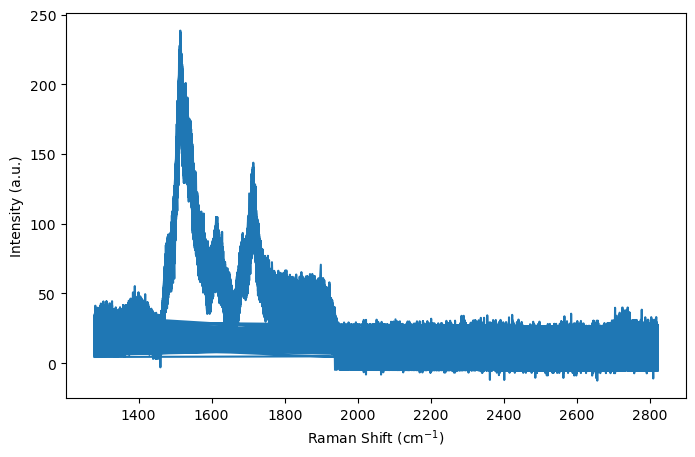

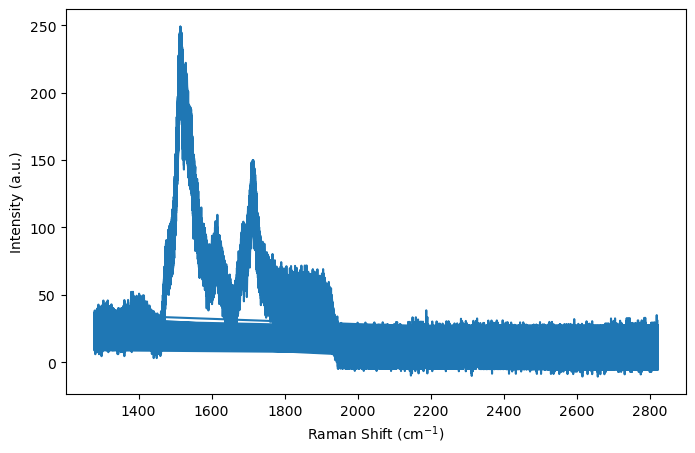

In [ ]:
import matplotlib.pyplot as plt
import glob
import numpy as np  

file_list = sorted(glob.glob("pt*.txt"))
filtered_spectra = []

plt.figure(figsize=(10, 6))

for file in file_list:
    data_array = np.loadtxt(file, usecols=(2, 3), delimiter='\t', unpack=True, skiprows=1)
    x, y = data_array
    
    # mask 1
    mask = y <= 250
    x_filtered = x[mask]
    y_filtered = y[mask]
    
    # mask 2D
    mask_range = (x_filtered >= 2000) & (x_filtered <= 2800) & (y_filtered > 40)
    x_filtered = x_filtered[~mask_range]
    y_filtered = y_filtered[~mask_range]

    
    mask_range2 = (x_filtered >= 1800) & (x_filtered <= 2000) & (y_filtered > 100)
    x_filtered = x_filtered[~mask_range2]
    y_filtered = y_filtered[~mask_range2]

    mask_range3 = (x_filtered >= 1200) & (x_filtered <= 1475) & (y_filtered > 100)
    x_filtered = x_filtered[~mask_range3]
    y_filtered = y_filtered[~mask_range3]

   
    mask_range4 = (x_filtered >= 1600) & (x_filtered <= 1800) & (y_filtered > 150)
    x_filtered = x_filtered[~mask_range4]
    y_filtered = y_filtered[~mask_range4]
    
    filtered_spectra.append((x_filtered, y_filtered))
    plt.plot(x_filtered, y_filtered, linestyle='-', label=file)

plt.xlabel('Raman Shift (cm$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.legend()
plt.show()

with open("filtered_spectra.txt", "w") as f:
    for x, y in filtered_spectra:
        for xi, yi in zip(x, y):
            f.write(f"{xi}\t{yi}\n")
        f.write("\n") 


for x_final, y_final in filtered_spectra:
    plt.figure(figsize=(8, 5))
    plt.plot(x_final, y_final, linestyle='-')
    plt.xlabel('Raman Shift (cm$^{-1}$)')
    plt.ylabel('Intensity (a.u.)')
    plt.show()
